# <span style="color:teal"> Lezione 1 </span>
In questa lezione vengono introdotte le tecniche Monte Carlo, una classe di metodi numerici basati sulla generazione di numeri casuali. L'idea fondamentale è di stimare quantità deterministiche attraverso una media su un campione finito di configurazioni generate stocasticamente. Poiché il campione è finito, ogni stima è affetta da un'incertezza statistica, la cui quantificazione è essenziale per valutare l'affidabilità dei risultati.

Data una variabile $A$, una misura naturale di tale incertezza è la **varianza** $\sigma^2_A$, che quantifica la dispersione dei valori attorno alla media:
$$\sigma^2_A := \langle (A-\langle A\rangle)^2\rangle = \langle A^2 \rangle -\langle A\rangle^2 $$

In generale in una simulazione Monte Carlo le misure successive non sono statisticamente indipendenti. Per ovviare a questo problema introduciamo il **metodo a blocchi**, che consente di ottenere una stima affidabile dell'errore statistico anche in presenza di autocorrelazioni temporali.

Consideriamo quindi una simulazione Monte Carlo che esegue complessivamente $M$ passi totali. Si suddividono gli $M$ passi in $N$ blocchi, ognuno dei quali composto da $L=M/N$ passi. All'interno di ogni blocco i-esimo si calcola una stima dell'osservabile $A_i$ e il corrispondente quadrato $A_i^2$. Le medie d'insieme vengono stimate come: 
    $$ \langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 $$
da cui si ricava l'incertezza statistica:
    $$\frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$

Da questa espressione è evidente che l'errore statistico scala come $1/\sqrt{N}$: all'aumentare del numero di blocchi, e quindi del numero totale di misure, l'incertezza diminuisce. Questo comportamento è in accordo con il **Teorema del Limite Centrale**, secondo cui la media di $N$ variabili aleatorie indipendenti e identicamente distribuite converge, per $N$ grande, a una distribuzione gaussiana con deviazione standard proporzionale a $1/\sqrt{N}$.

## <span style="color:turquoise"> Esercizio 1.1 </span>
In questo esercizio, attraverso l'utilizzo di un generatore di numeri pseudo-casuali e il metodo del data blocking, è stato chiesto di stimare e graficare le seguenti quantità:

1. il valor medio di $r$ sull'intervallo $[0,1]$: $\langle r \rangle = \int_0^1 r dr = 1/2$ con la sua incertezza statistica corrispondente alla deviazione standard della media. I campioni $r$ sono estratti direttamente da una distribuzione uniforme in $[0,1)$, così da far convergere la media campionaria al valore atteso $1/2$ per la legge dei grandi numeri. Per questa simulazione sono stati utilizzati $M_B=10^4$ step suddivisi in $N=100$ blocchi.

2. la varianza di $r$ sull'intervallo $[0,1]$: $\sigma^2 = \int_0^1 (r-1/2)^2 dr = 1/12$ con la sua incertezza statistica corrispondente alla deviazione standard della media. Utilizzando gli stessi campioni uniformi in $[0,1)$, si stima $\sigma^2$ come media campionaria di $(r-1/2)^2$, che ha come valor medio teorico $1/12$. Per questa simulazione sono stati utilizzati $M_B=10^4$ step suddivisi in $N=100$ blocchi.

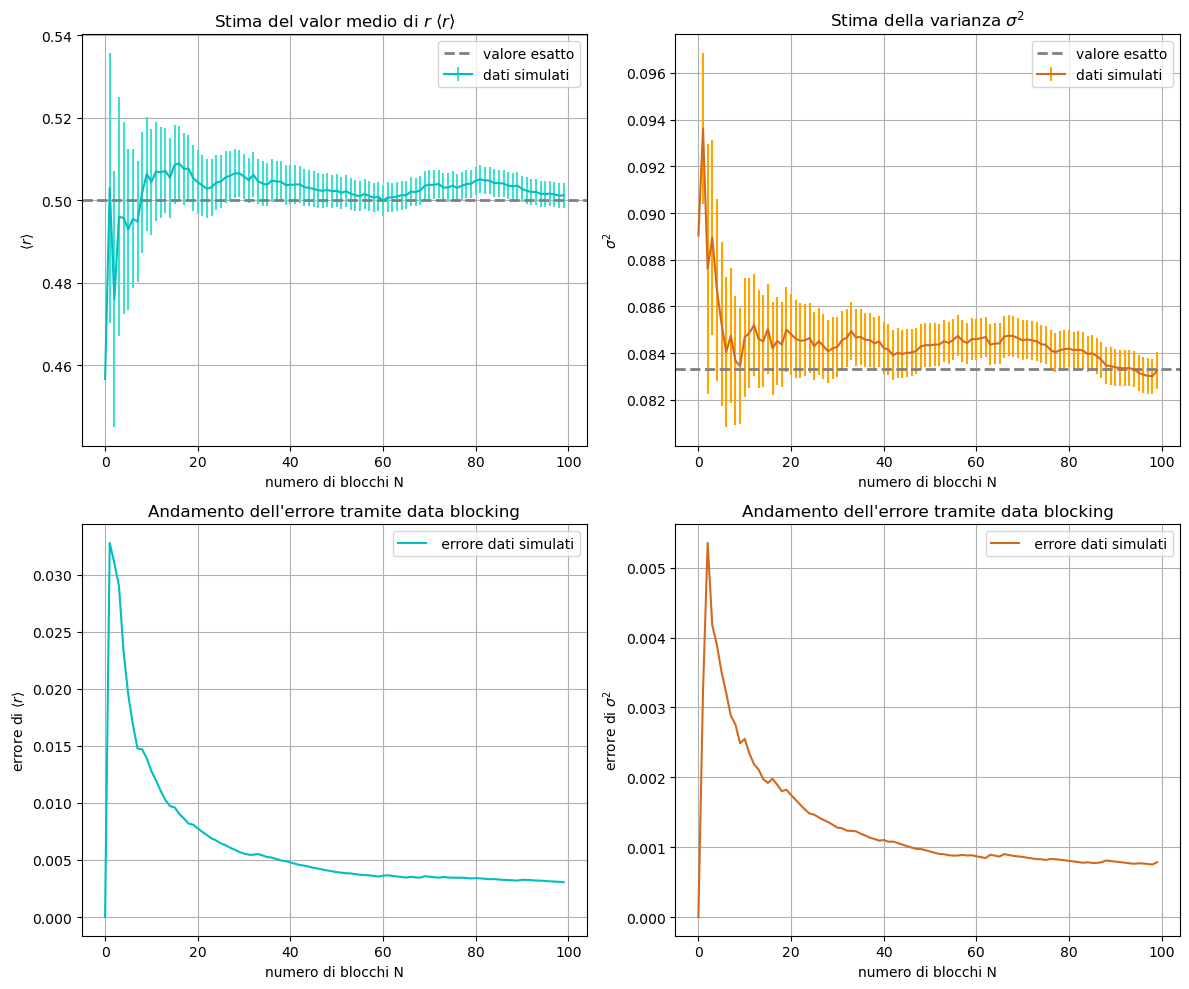

In [2]:
# stima <r> e sigma^2
import numpy as np
import matplotlib.pyplot as plt

N=100
x = np.arange(N)

dati=np.loadtxt("Esercizio1.1/dati1.txt")
sum_prog_r=dati[:,0]
err_prog_r=dati[:,1]

dati=np.loadtxt("Esercizio1.1/dati2.txt")
sum_prog_var=dati[:,0]
err_prog_var=dati[:,1]


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
ax1.errorbar(x,sum_prog_r,yerr=err_prog_r, color='c', ecolor='turquoise', label='dati simulati')
ax1.axhline(y=0.5, ls='--', color='grey', lw=2, label='valore esatto')
ax1.set_xlabel('numero di blocchi N')
ax1.set_ylabel(r'$\langle r \rangle$')
ax1.set_title(r"Stima del valor medio di $r$ $\langle r \rangle$")
ax1.grid(True)
ax1.legend()

ax2.errorbar(x,sum_prog_var,yerr=err_prog_var,color='chocolate', ecolor='orange', label='dati simulati')
ax2.axhline(y=1/12, ls='--', color='grey', lw=2, label='valore esatto')
ax2.set_xlabel('numero di blocchi N')
ax2.set_ylabel('$\sigma^2$')
ax2.set_title("Stima della varianza $\sigma^2$")
ax2.grid(True)
ax2.legend()


ax3.plot(x,err_prog_r, color='c', label=' errore dati simulati')
ax3.set_xlabel("numero di blocchi N")
ax3.set_ylabel(rf"errore di $\langle r \rangle$")
ax3.set_title("Andamento dell'errore tramite data blocking")
ax3.grid(True)
ax3.legend()

ax4.plot(x,err_prog_var, color='chocolate', label=' errore dati simulati')
ax4.set_xlabel("numero di blocchi N")
ax4.set_ylabel(rf"errore di $\sigma^2$")
ax4.set_title("Andamento dell'errore tramite data blocking")
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

I grafici in alto mostrano la stima cumulativa progressiva di $\langle r \rangle$ e $\sigma^2$ in funzione del numero di blocchi $N$, con le relative barre d'errore calcolate tramite il metodo del data blocking. I grafici in basso mostrano l'andamento dell'errore di $\langle r \rangle$ e $\sigma^2$ in funzione del numero di blocchi $N$.

In entrambi i casi il comportamento è quello caratteristico del metodo: per i primi blocchi la stima oscilla in modo apprezzabile e le barre d'errore sono molto ampie, poiché con pochi blocchi accumulati la statistica è scarsa e la stima dell'incertezza è ancora poco affidabile. Al crescere di $N$ le medie cumulative si stabilizzano e le barre d'errore si riducono progressivamente seguendo l'andamento atteso $\sim 1\sqrt{N}$, fino a convergere ai rispettivi valori esatti indicati dalle linee tratteggiate grigie.

Il fatto che entrambe le stime finali siano compatibili con i valori teorici entro le barre d'errore ci dà una prima conferma che il generatore pseudo-casuale produce numeri distribuiti in modo statisticamente uniforme e che il metodo del data blocking fornisce una stima corretta e controllata dell'incertezza statistica.

3. Per verificare la compatibilità della distribuzione dei numeri generati con la distribuzione uniforme, si implementa il test del $\chi^2$ di Pearson. Questa statistica misura lo scarto globale tra le osservazione $O_i$ e i valori attesi $E_i$:
$$\chi^2 = \sum_{i} \frac{\left( O_i - E_i \right)^2}{E_i}$$
Il numeratore quantifica la distanza al quadrato tra osservazioni e valori attesi, normalizzata al denominatore dalla varianza attesa della distribuzione di riferimento, che per conteggi binomiali con $p$ piccolo coincide con il valore atteso stesso $E_i$.

    Dividiamo l'intervallo $[0,1]$ in $M=100$ sottointervalli di uguale ampiezza. Poiché la distribuzione è uniforme, la probabilità che un singolo numero casuale cada in un dato sottointervallo è $p=1/M=1/100$, uguale per tutti i bin, quindi il numero atteso di eventi in ciascun bin dopo aver generato $n$ numeri pseudo-casuali è $n/M$. Il test viene ripetuto 100 volte su blocchi successivi di $n$ numeri. In questo caso la statistica diventa:

    $$\chi^2 = \sum_{i=1}^M \frac{\left( n_i - n/M \right)^2}{n/M}$$

    Ci aspettiamo in media che $(n_i-n/M)^2 \approx n/M$ e quindi $\chi^2\approx 100$, ovvero pari al numero di sottointervalli. Un valore significativamente superiore indicherebbe che l'ipotesi che gli $n_i$ siano estratti da una distribuzione uniforme è piuttosto improbabile. 

    Per una valutazione più rigorosa, l'istogramma dei 100 valori $\chi_j^2$ ottenuti viene confrontato con la distribuzione teorica del $\chi^2$ con $M-1=99$ gradi di libertà: solo se i valori simulati risultano compatibili con tale distribuzione possiamo concludere che il generatore si comporta in modo statisticamente uniforme.

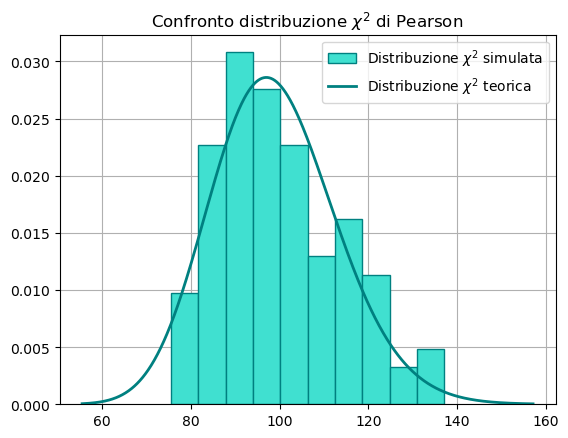

Il valor medio di chi quadro è: 99.91 +/- 1.40


In [3]:
# grafico e stampa valor medio chi^2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

chiquadro = np.loadtxt("Esercizio1.1/datichi.txt")

x_chi = np.linspace(chiquadro.min()-20, chiquadro.max()+20, 1000)

plt.hist(chiquadro, density=True, label="Distribuzione $\chi^2$ simulata", color='turquoise',edgecolor='teal', zorder=2)
plt.plot(x_chi, stats.chi2.pdf(x_chi, df=99), label="Distribuzione $\chi^2$ teorica ", color='teal', lw=2, zorder=3)
plt.title(r"Confronto distribuzione $\chi^2$ di Pearson")
plt.legend()
plt.grid()
plt.show()



media_chi = chiquadro.mean()
std = chiquadro.std(ddof=1)        # ddof=1 → divisione per N-1 (stima corretta della std)
errore_media = std / np.sqrt(N)    # errore standard della media

print(f"Il valor medio di chi quadro è: {float(media_chi):.2f} +/- {float(errore_media):.2f}")

Nel grafico è riportato l'istogramma dei 100 valori $\chi_j^2$ ottenuti, confrontato con con la distribuzione teorica del $\chi^2$ con $M-1=99$ gradi di libertà. Il valor medio della distribuzione $\chi^2$ è in ottimo accordo con il valore teorico atteso $E_{\chi^2}=99 $ e i dati appaiono distribuiti in modo equilibrato attorno a tale valore. Inoltre, non si evidenziano deviazioni sistematiche tra i risultati simulati e la curva teorica: l’istogramma riproduce con buona accuratezza l’andamento previsto su tutto il dominio, comprese le regioni di coda, dove sono naturalmente presenti fluttuazioni più ampie. Si può quindi concludere che non emergono evidenze statisticamente significative tali da giustificare il rigetto dell’ipotesi di uniformità dei numeri pseudo-casuali utilizzati.

## <span style="color:turquoise"> Esercizio 1.2 </span>
In questo esericizio è stato chiesto di aggiungere al generatore di numeri pseudo-casuali le distribuzioni esponenziale $p(x)=\lambda e^{-\lambda x}$ e di Cauchy-Lorentz $p(x)=\frac{1}{\pi}\frac{\Gamma}{(x-\mu)^2+\Gamma^2}$. 

Esse sono state implementate attraverso il metodo dell'inversione della funzione cumulativa $F(x)$: se $u\sim U(0,1)$ è distribuita uniformente tra $[0,1)$ allora la variabile $x=F^{-1}(u)$ è distribuita secondo $p(x)$ con $F(x)=\int _{-\infty}^x p(t)dt$.  

Per entrambe le distribuzioni le inverse si ricavano analiticamente:

- distribuzione esponenziale: la cumulativa è $F(x)=1- e^{-\lambda x}$ da cui si ottiene $x=F^{-1}(u)=-1/{\lambda}\, \text{ln}(1-u)$.

- distribuzione di Cauchy-Lorentz: la cumulativa è $F(x)=\frac{1}{2} +\frac{1}{\pi} \text{arctan} \left ( \frac{x-\mu}{\Gamma} \right ) $ da cui si ottiene $x=F^{-1}(u)=\mu +\Gamma \, \text{tan}(\pi(u-1/2))$.

L'obiettivo dell'esercizio è verficare il **Teorema di Lévy–Khintchine** che afferma che una densità di probabilità può essere la distribuzione limite della somma di variabili aleatorie indipendenti e identicamente distribuite se e solo se è stabile. Le distribuzioni stabili sono quindi le uniche candidate a descrivere il comportamento della media campionaria $S_N = \frac{1}{N}\sum_{i=1}^N x_i$ al crescere di $N$. Il Teorema del Limite Centrale ne è il caso più noto: se la distribuzione di partenza ha varianza finita, l'unica distribuzione stabile compatibile è la gaussiana e $S_N$ converge ad essa indipendentemente dalla forma originale di $p(x)$.

Per verificare ciò si effettuano $M=10^4$ realizzazioni di $S_N$ per un dado standard, per una distribuzione esponenziale con $\lambda=1$ e per una distribuzione di Cauchy-Lorentz con $\mu=0$ e $\Gamma=1$,  riempiendo quattro istogrammi per $N=1, 2, 10, 100$ tramite il metodo del data blocking.
Per il dado e l'esponenziale, che hanno varianza finita, ci aspettiamo che la distribuzione di $S_N$ si avvicini progressivamente a una gaussiana al crescere di $N$.
La Cauchy-Lorentz costituisce invece un controesempio: la varianza infinita esclude l'applicabilità del Teorema del Limite Centrale, ma la stabilità della distribuzione garantisce che la forma di $S_N$ rimanga lorentziana a qualunque $N$.


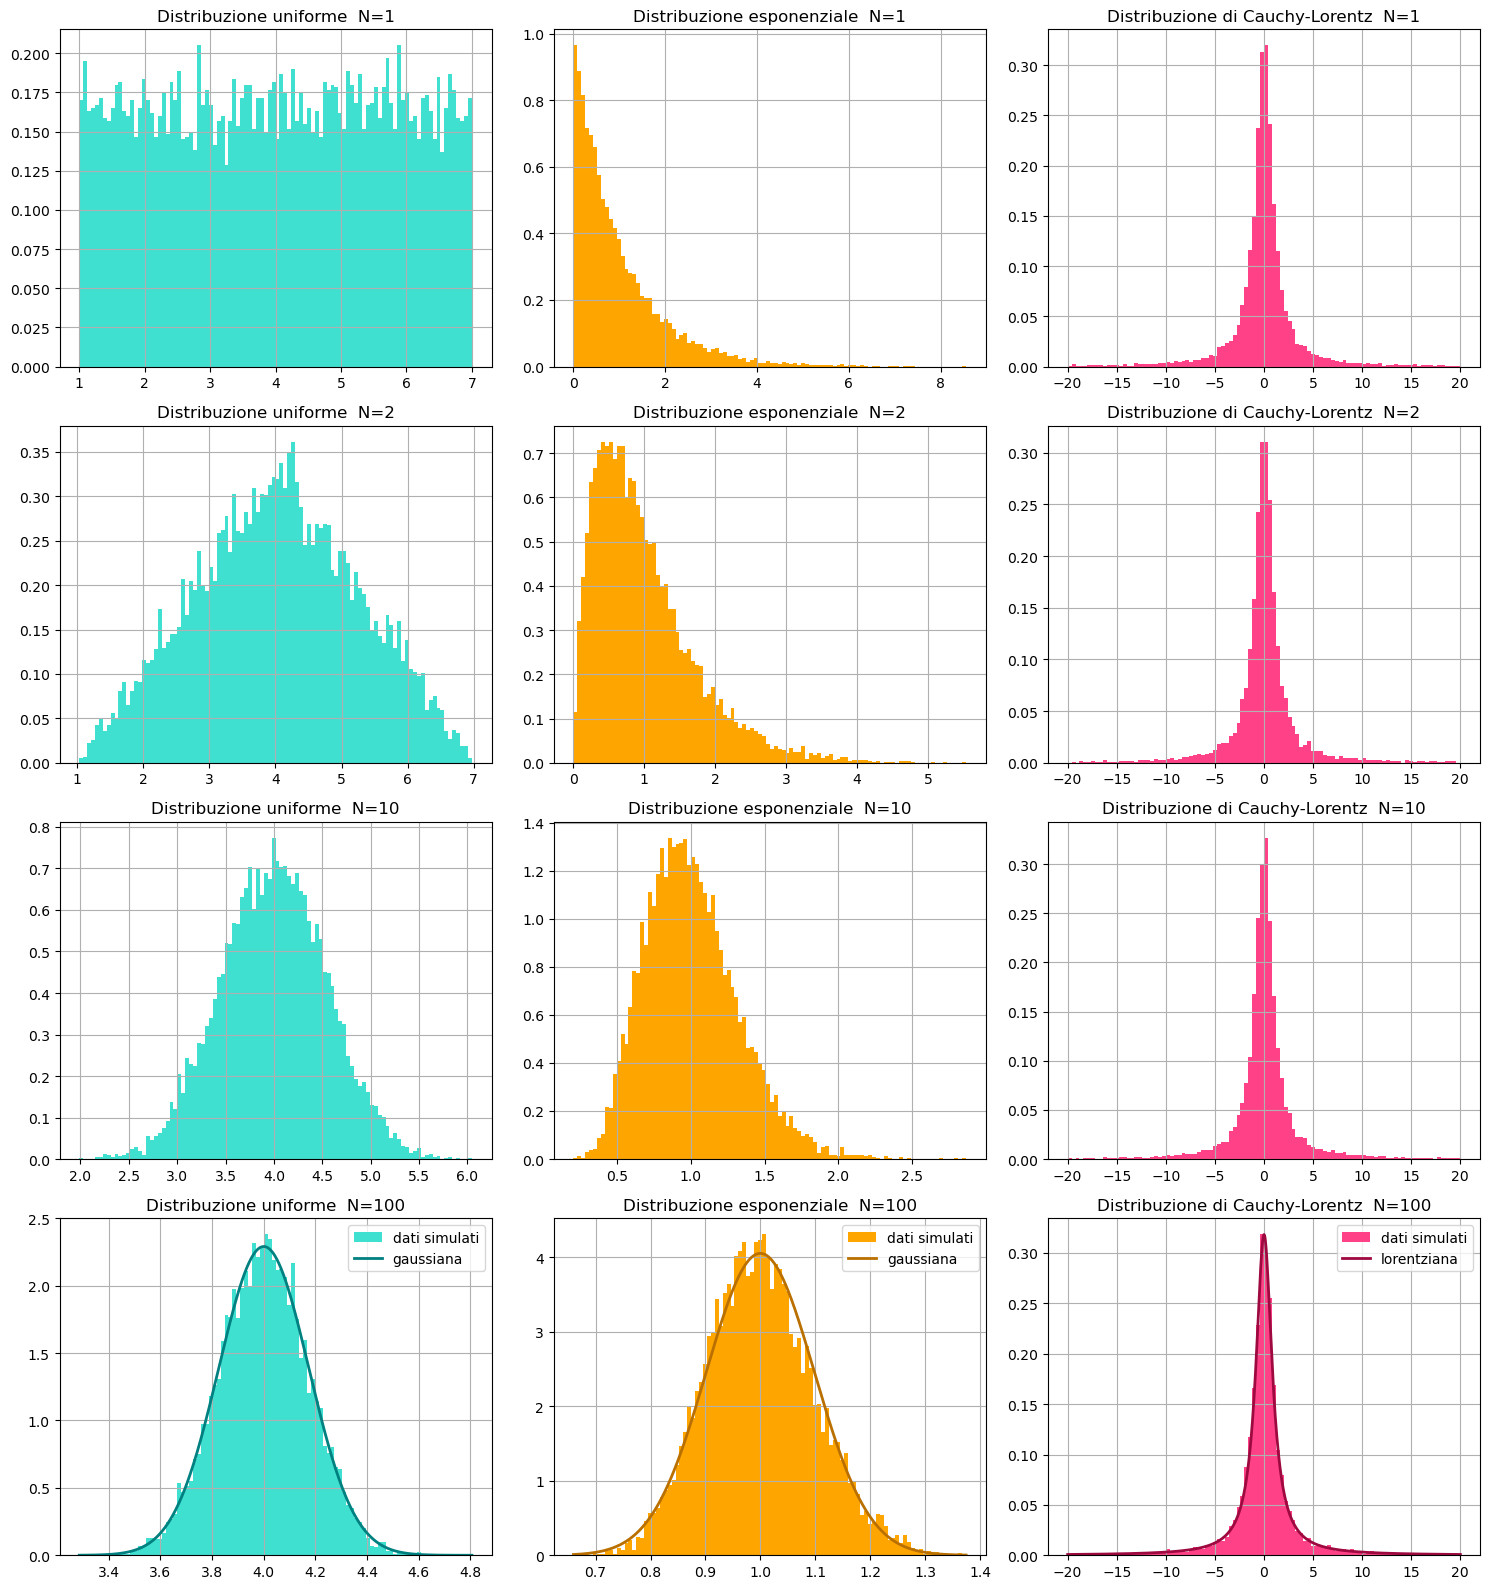

In [6]:
# grafici gaussiana, esponenziale e Cauchy
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

N = [1, 2, 10, 100]
unif, expo, lorentz = [], [], []

for n in N:
    dati = np.loadtxt(f"Esercizio1.2/dati{n}.txt")
    unif.append(dati[:, 0])
    expo.append(dati[:, 1])
    lorentz.append(dati[:, 2])

fig, ax = plt.subplots(4, 3, figsize=(15, 16))

col_colors = ["turquoise", "orange", "#ff4287"]
col_titles = ["Uniforme", "Esponenziale", "Lorentziana"]

for i, n in enumerate(N):
    # --- Colonna 0: Uniforme ---
    ax[i, 0].hist(unif[i], density=True, bins=100, color="turquoise", label="dati simulati")
    ax[i, 0].set_title(f"Distribuzione uniforme  N={n}")
    ax[i, 0].grid(True)

    # --- Colonna 1: Esponenziale ---
    ax[i, 1].hist(expo[i], density=True, bins=100, color="orange", label="dati simulati")
    ax[i, 1].set_title(f"Distribuzione esponenziale  N={n}")
    ax[i, 1].grid(True)

    # --- Colonna 2: Lorentziana ---
    ax[i, 2].hist(lorentz[i], range=(-20, 20), bins=100, density=True,
                  color="#ff4287", label="dati simulati")
    ax[i, 2].set_title(f"Distribuzione di Cauchy-Lorentz  N={n}")
    ax[i, 2].grid(True)

# Gaussiana su uniforme (N=100, riga 3)
m, s = unif[3].mean(), unif[3].std()
x = np.linspace(unif[3].min(), unif[3].max(), 1000)
ax[3, 0].plot(x, stats.norm.pdf(x, loc=m, scale=s), color="teal", lw=2, label="gaussiana")
ax[3, 0].legend()

# Gaussiana su esponenziale (N=100, riga 3)
m, s = expo[3].mean(), expo[3].std()
x = np.linspace(expo[3].min(), expo[3].max(), 1000)
ax[3, 1].plot(x, stats.norm.pdf(x, loc=m, scale=s), color="#ba7000", lw=2, label="gaussiana")
ax[3, 1].legend()

# Lorentziana su lorentziana (N=100, riga 3)
x = np.linspace(-20, 20, 1000)
ax[3, 2].plot(x, stats.cauchy.pdf(x, loc=0, scale=1), color="#9e0940", lw=2, label="lorentziana")
ax[3, 2].legend()

plt.tight_layout()
plt.show()

In figura sono riportati i risultati ottenuti: in azzurro nella colonna di sinistra sono rappresentati gli istogrammi per la distribuzione uniforme, in arancione nella colonna centrale sono rappresentati gli istogrammi per la distribuzione esponenziale e in magenta nella colonna di destra sono rappresentati gli istogrammi per la distribuzione di Cauchy-Lorentz.

Per la distribuzione uniforme e quella esponenziale la convergenza alla gaussiana è evidente: a $N=10$ la forma a campana è già riconoscibile, e a $N=100$ l'accordo con la curva teorica è ottimo. 

Invece, la distribuzione di Cauchy-Lorentz si comporta in modo completamente diverso: la forma degli istogrammi rimane lorentziana a qualunque $N$. Per $N=100$ la sovrapposizione con la lorentziana teorica conferma che $S_N$ ha esattamente la stessa distribuzione del singolo campione, grazie alla stabilità della distribuzione.

## <span style="color:turquoise"> Esercizio 1.3 </span>
In questo esercizio è stato chiesto di simulare l'esperimento di Bouffon tramite il metodo del data blocking, con $M=10^5$ lanci totali suddivisi in $N=100$ blocchi.

Quando un ago di lunghezza $L$ viene lanciato casualmente su un piano attraversato da righe orizzontali distanziate di $d$, la probabilità che intersechi una di esse è $P=2L/\pi d$. Invertendo questa relazione, se l'ago viene lanciato $N_{thr}$ volte e interseca una linea $N_{hit}$ volte, si ottiene la stima:
$$\pi = \frac{2L}{Pd} = \lim_{N_{thr} \to \infty}\frac{2LN_{thr}}{N_{hit}d}$$

Per la simulazione sono stati scelti i parametri $L=0.9$ e $d=1$. Ogni lancio è caratterizzato da due variabili casuali uniformi:
- la posizione del centro dell'ago $x_0 \sim U(0,d)$
- l'angolo d'inclinazione dell'ago $\theta \sim U(0, \pi)$ 

L'ago interseca una riga se la distanza dal centro alla linea più vicina $\delta$ soddisfa: $ \delta \leq \frac{L}{2}\text{sin}\,\theta$

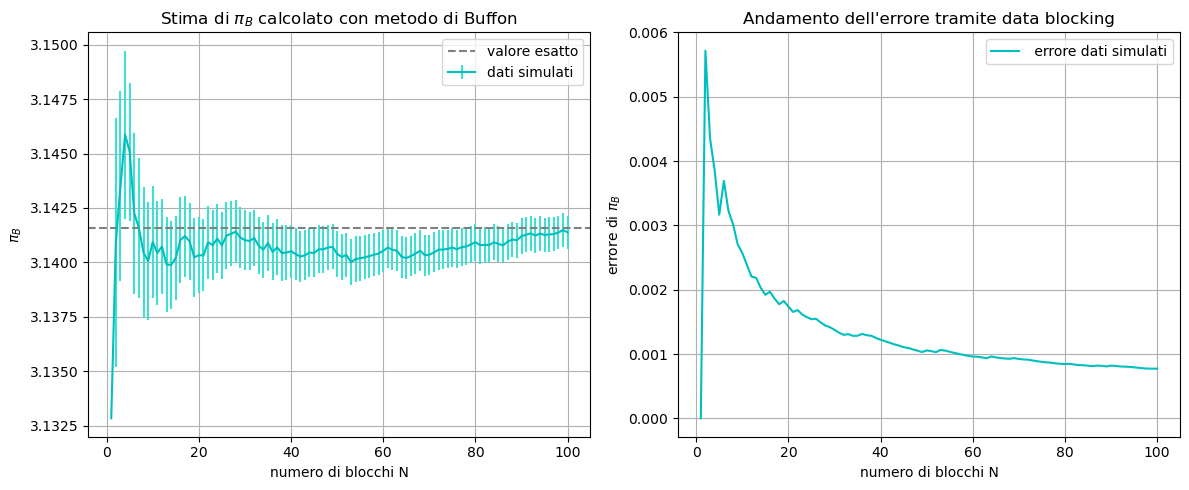

In [7]:
# grafici media a blocchi e errore

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
             
N=100                 

x = np.arange(N)
pigreco = np.zeros(N)
error = np.zeros(N)

dati=np.loadtxt("Esercizio1.3/dati.txt")
x=dati[:,0]
pigreco=dati[:,1]
error=dati[:,2]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.errorbar(x, pigreco, yerr=error, color='c', ecolor='turquoise', label='dati simulati')
ax1.axhline(y=np.pi, color='grey', ls='--', label='valore esatto')
ax1.set_xlabel("numero di blocchi N")
ax1.set_ylabel(rf"$\pi_B$")
ax1.set_title(fr"Stima di $\pi_B$ calcolato con metodo di Buffon")
ax1.grid(True)
ax1.legend()

ax2.plot(x,error, color='c', label=' errore dati simulati')
ax2.set_xlabel("numero di blocchi N")
ax2.set_ylabel(rf"errore di $\pi_B$")
ax2.set_title(fr"Andamento dell'errore tramite data blocking")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Nel grafico di sinistra è riportata la stima progressiva di $\pi_B$ al crescere del numero di blocchi $N$, con le relative barre d'errore (deviazione standard della media). Si osserva che per piccoli valori di $N$ la stima è instabile e le fluttuazioni sono ampie. Al crescere di $N$ la curva si stabilizza rapidamente attorno al valore esatto (linea tratteggiata), rimanendo compatibile con esso entro le barre d'errore per tutto il resto della simulazione.

Nel grafico di destra è mostrato l'andamento dell'errore statistico in funzione di $N$. Come atteso, l'incertezza decresce con un andamento compatibile con $1/\sqrt{N}$.